In [1]:
import os
from dotenv import load_dotenv
from pyjstat import pyjstat
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

import pymongo
import psycopg2
import pandas as pd
import requests

In [ ]:
# download data 
api_url = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/CJQ06/JSON-stat/1.0/en"
response = requests.get(api_url)

# extract the JSON-STAT file and store it into data frame of pandas
dataset = pyjstat.Dataset.read(response.text)
df = dataset.write('dataframe')

# load env variable to notebook
load_dotenv(override=True)
# call and store mongoDB protected detail
mongo_url = os.getenv("MONGO_URI")
if mongo_url:
    print(f"Load URI successfully: {len(mongo_url)} ")
else:
    print("Warning: Can not find MONGO_URI in file .env!")

# connect to MongoDB
client = pymongo.MongoClient(mongo_url)
db = client['IE_Crime_Project']
collection = db['raw_crime_data']

# convert df to dictionary to pull into MongoDB
data_dict = df.to_dict(orient='records')
collection.drop() 
collection.insert_many(data_dict)

In [2]:
load_dotenv(override=True)
# call and store mongoDB protected detail
mongo_url = os.getenv("MONGO_URI")
client = pymongo.MongoClient(mongo_url)
db = client['IE_Crime_Project']
collection = db['raw_crime_data']
# Fetch data from the MongoDB
raw_data = list(collection.find())
# Convert JSON to dataframe
df = pd.DataFrame(raw_data)

c:\Users\DELL\Anaconda\Lib\site-packages\pymongo\pyopenssl_context.py:348: CryptographyDeprecationWarning: Parsed a serial number which wasn't positive (i.e., it was negative or zero), which is disallowed by RFC 5280. Loading this certificate will cause an exception in a future release of cryptography.
  _crypto.X509.from_cryptography(x509.load_der_x509_certificate(cert))


# DATA EXPLORATION + PREPARATION START !

In [3]:
df.columns

Index(['_id', 'Statistic', 'Quarter', 'Garda Division', 'Type of Offence',
       'value'],
      dtype='object')

In [4]:
df.head(5)

,_id,Statistic,Quarter,Garda Division,Type of Offence,value
0,69e624fe4c5f6ad674e4c1b0,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Manslaughter (0112),0.0
1,69e624fe4c5f6ad674e4c1b8,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Threat to kill or cause serious harm (0313),0.0
2,69e624fe4c5f6ad674e4c1bb,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Other assault (035),94.0
3,69e624fe4c5f6ad674e4c1bc,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Dangerous or negligent acts (04),160.0
4,69e624fe4c5f6ad674e4c1be,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Driving/In charge of a vehicle while intoxicat...,120.0


In [5]:

# Drop the id column automatically generated by MongoDB
if '_id' in df.columns:
    df = df.drop(columns=['_id'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218960 entries, 0 to 218959
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Statistic        218960 non-null  object 
 1   Quarter          218960 non-null  object 
 2   Garda Division   218960 non-null  object 
 3   Type of Offence  218960 non-null  object 
 4   value            218456 non-null  float64
dtypes: float64(1), object(4)
memory usage: 8.4+ MB


In [7]:
df.describe()

,value
count,218456.000000
mean,74.241811
std,189.542564
min,0.000000
25%,0.000000
50%,6.000000
75%,62.000000
max,4377.000000


In [8]:
null_rows = df[df['value'].isnull()]
print(len(null_rows))
print(null_rows)

504
                       Statistic Quarter                       Garda Division  \
195301  Recorded crime incidents  2023Q3                 Louth Garda Division   
195337  Recorded crime incidents  2023Q3        Cavan/Monaghan Garda Division   
195422  Recorded crime incidents  2023Q3         Sligo/Leitrim Garda Division   
195470  Recorded crime incidents  2023Q3               Donegal Garda Division   
195661  Recorded crime incidents  2023Q3    Roscommon/Longford Garda Division   
...                          ...     ...                                  ...   
218827  Recorded crime incidents  2025Q4             Waterford Garda Division   
218853  Recorded crime incidents  2025Q4  D.M.R. North Central Garda Division   
218896  Recorded crime incidents  2025Q4        D.M.R. Western Garda Division   
218916  Recorded crime incidents  2025Q4       D.M.R. Northern Garda Division   
218925  Recorded crime incidents  2025Q4       D.M.R. Southern Garda Division   

                       

In [9]:
null_rows.nunique()

Statistic           1
Quarter            10
Garda Division     28
Type of Offence     3
value               0
dtype: int64

In [10]:
for i in null_rows.columns:
    print(null_rows[i].unique())
    print("-" * 30)

['Recorded crime incidents']
------------------------------
['2023Q3' '2023Q4' '2024Q1' '2024Q2' '2024Q3' '2024Q4' '2025Q1' '2025Q2'
 '2025Q3' '2025Q4']
------------------------------
['Louth Garda Division' 'Cavan/Monaghan Garda Division'
 'Sligo/Leitrim Garda Division' 'Donegal Garda Division'
 'Roscommon/Longford Garda Division' 'Clare Garda Division'
 'Mayo Garda Division' 'Cork City Garda Division' 'Galway Garda Division'
 'Cork North Garda Division' 'Laois/Offaly Garda Division'
 'Meath Garda Division' 'Cork West Garda Division'
 'Limerick Garda Division' 'Kerry Garda Division' 'Wicklow Garda Division'
 'Waterford Garda Division' 'Westmeath Garda Division'
 'Tipperary Garda Division' 'Kildare Garda Division'
 'Kilkenny/Carlow Garda Division' 'Wexford Garda Division'
 'D.M.R. Northern Garda Division' 'D.M.R. Southern Garda Division'
 'D.M.R. South Central Garda Division' 'D.M.R. Eastern Garda Division'
 'D.M.R. North Central Garda Division' 'D.M.R. Western Garda Division']
-------

In [11]:
# fill the null data point in the value column by 0 
df['value'] = df['value'].fillna(0)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe(include=['object'])

,Statistic,Quarter,Garda Division,Type of Offence
count,218960,218960,218960,218960
unique,1,92,28,85
top,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Manslaughter (0112)
freq,218960,2380,7820,2576


In [14]:
non_numeric_df = df.select_dtypes(exclude=['number'])
for i in non_numeric_df:
    print(df[i].unique())
    print(len(df[i].unique()))
    print("-" * 30)

['Recorded crime incidents']
1
------------------------------
['2003Q1' '2003Q2' '2003Q3' '2003Q4' '2004Q1' '2004Q2' '2004Q3' '2004Q4'
 '2005Q1' '2005Q2' '2005Q3' '2005Q4' '2006Q1' '2006Q2' '2006Q3' '2006Q4'
 '2007Q1' '2007Q2' '2007Q3' '2007Q4' '2008Q1' '2008Q2' '2008Q3' '2008Q4'
 '2009Q1' '2009Q2' '2009Q3' '2009Q4' '2010Q1' '2010Q2' '2010Q3' '2010Q4'
 '2011Q1' '2011Q2' '2011Q3' '2011Q4' '2012Q1' '2012Q2' '2012Q3' '2012Q4'
 '2013Q1' '2013Q2' '2013Q3' '2013Q4' '2014Q1' '2014Q2' '2014Q3' '2014Q4'
 '2015Q1' '2015Q2' '2015Q3' '2015Q4' '2016Q1' '2016Q2' '2016Q3' '2016Q4'
 '2017Q1' '2017Q2' '2017Q3' '2017Q4' '2018Q1' '2018Q2' '2018Q3' '2018Q4'
 '2019Q1' '2019Q2' '2019Q3' '2019Q4' '2020Q1' '2020Q2' '2020Q3' '2020Q4'
 '2021Q1' '2021Q2' '2021Q3' '2021Q4' '2022Q1' '2022Q2' '2022Q3' '2022Q4'
 '2023Q1' '2023Q2' '2023Q3' '2023Q4' '2024Q1' '2024Q2' '2024Q3' '2024Q4'
 '2025Q1' '2025Q2' '2025Q3' '2025Q4']
92
------------------------------
['Cavan/Monaghan Garda Division' 'Donegal Garda Division'
 'Sli

In [15]:
non_integer_rows = df[df['value'] % 1 != 0]

print(non_integer_rows)

Empty DataFrame
Columns: [Statistic, Quarter, Garda Division, Type of Offence, value]
Index: []


In [22]:
# Extract year and quarter from quarter column 
df['year'] = df['Quarter'].str[:4].astype(int)

df['quarter_number'] = df['Quarter'].str[-1].astype(int)

# Check
print(df[['Quarter', 'year', 'quarter_number']].head())
print(df[['Quarter', 'year', 'quarter_number']].tail())

  Quarter  year  quarter_number
0  2003Q1  2003               1
1  2003Q1  2003               1
2  2003Q1  2003               1
3  2003Q1  2003               1
4  2003Q1  2003               1
       Quarter  year  quarter_number
218955  2025Q4  2025               4
218956  2025Q4  2025               4
218957  2025Q4  2025               4
218958  2025Q4  2025               4
218959  2025Q4  2025               4


In [23]:
print(df['year'].unique())
print(df['year'].dtype)
print("-"*30)
print(df['quarter_number'].unique())
print(df['quarter_number'].dtype)

[2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024 2025]
int64
------------------------------
[1 2 3 4]
int64


In [24]:
# extract county from garda division
df['County'] = df['Garda Division'].str.replace(' Garda Division', '', case=False).str.strip()

# Check result
print(df[['Garda Division', 'County']].drop_duplicates().head())
print(df[['Garda Division', 'County']].drop_duplicates().tail())

                   Garda Division          County
0   Cavan/Monaghan Garda Division  Cavan/Monaghan
12         Donegal Garda Division         Donegal
22   Sligo/Leitrim Garda Division   Sligo/Leitrim
35           Louth Garda Division           Louth
44           Clare Garda Division           Clare
                           Garda Division                County
1560  D.M.R. North Central Garda Division  D.M.R. North Central
2001       D.M.R. Northern Garda Division       D.M.R. Northern
2016       D.M.R. Southern Garda Division       D.M.R. Southern
2029        D.M.R. Eastern Garda Division        D.M.R. Eastern
2040        D.M.R. Western Garda Division        D.M.R. Western


In [25]:
print(len(df['Garda Division'].unique()))
print("-"*30)
print(df['County'].unique())
print(len(df['County'].unique()))
print(len(df['County'].dtype))

28
------------------------------
['Cavan/Monaghan' 'Donegal' 'Sligo/Leitrim' 'Louth' 'Clare' 'Mayo'
 'Galway' 'Roscommon/Longford' 'Cork City' 'Cork North' 'Cork West'
 'Kerry' 'Limerick' 'Laois/Offaly' 'Meath' 'Wicklow' 'Westmeath' 'Kildare'
 'Tipperary' 'Wexford' 'Kilkenny/Carlow' 'Waterford'
 'D.M.R. South Central' 'D.M.R. North Central' 'D.M.R. Northern'
 'D.M.R. Southern' 'D.M.R. Eastern' 'D.M.R. Western']
28
0


C:\Users\DELL\AppData\Local\Temp\ipykernel_253052\3053276482.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(labels)
C:\Users\DELL\AppData\Local\Temp\ipykernel_253052\3053276482.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(labels)


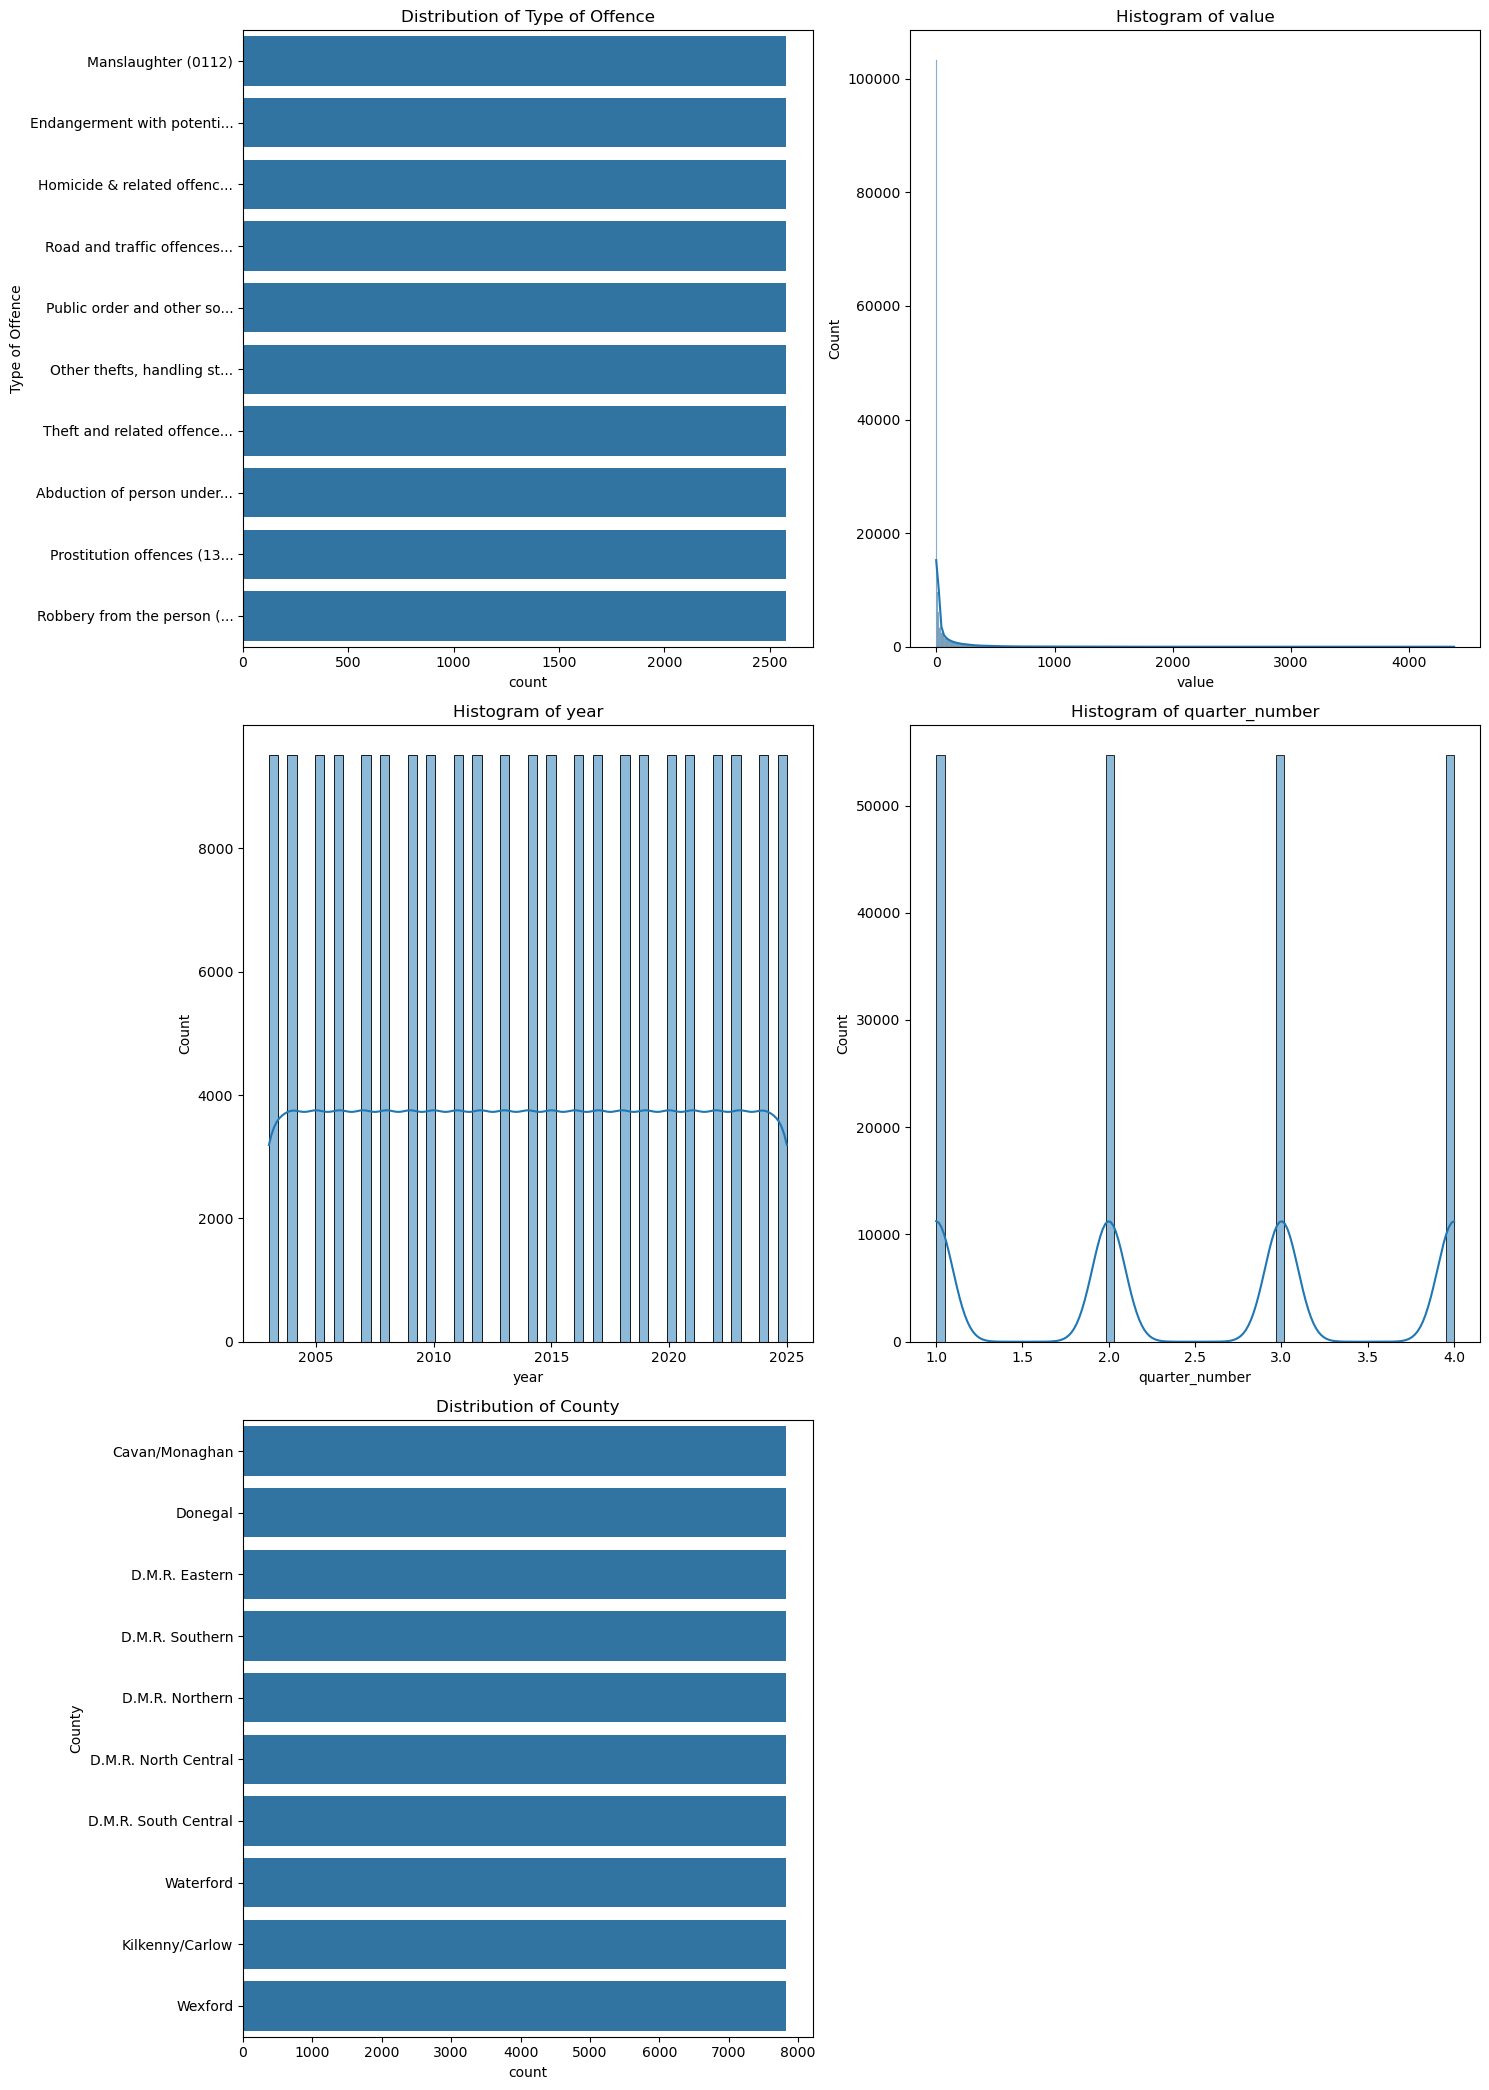

In [26]:
# exclude columns
exclude_cols = ['Quarter', 'Garda Division', 'Statistic']

# Filter to get the columns which are not in the excluding list
cols_to_plot = [col for col in df.columns if col not in exclude_cols]

# Create Subplots
n_plot = len(cols_to_plot)
nrows = (n_plot + 1) // 2
ncols = min(n_plot, 2)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 7 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if df[col].dtype == 'object':
        # Ibject: count plot
        top_values = df[col].value_counts().head(10).index
        labels = [(str(x)[:25] + '...') if len(str(x)) > 25 else str(x) for x in top_values]
        sns.countplot(data=df[df[col].isin(top_values)], y=col, ax=axes[i], order=top_values)
        axes[i].set_yticklabels(labels)
        axes[i].set_title(f'Distribution of {col}')
    else:
        # Numeric: Histogram plot
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {col}')

# Delete redundant subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [27]:
df['value'].max()

4377.0

In [28]:
df[df['value'] > 4000]

,Statistic,Quarter,Garda Division,Type of Offence,value,year,quarter_number,County
35518,Recorded crime incidents,2006Q3,D.M.R. Western Garda Division,Dangerous or negligent acts (04),4377.0,2006,3,D.M.R. Western
45016,Recorded crime incidents,2007Q3,D.M.R. Western Garda Division,Dangerous or negligent acts (04),4142.0,2007,3,D.M.R. Western
52404,Recorded crime incidents,2008Q2,D.M.R. Western Garda Division,Road and traffic offences (14),4039.0,2008,2,D.M.R. Western


In [29]:
df.head(10)

,Statistic,Quarter,Garda Division,Type of Offence,value,year,quarter_number,County
0,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Manslaughter (0112),0.0,2003,1,Cavan/Monaghan
1,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Threat to kill or cause serious harm (0313),0.0,2003,1,Cavan/Monaghan
2,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Other assault (035),94.0,2003,1,Cavan/Monaghan
3,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Dangerous or negligent acts (04),160.0,2003,1,Cavan/Monaghan
4,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Driving/In charge of a vehicle while intoxicat...,120.0,2003,1,Cavan/Monaghan
5,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,False imprisonment (0511),1.0,2003,1,Cavan/Monaghan
6,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,"Robbery, extortion and hijacking offences (06)",2.0,2003,1,Cavan/Monaghan
7,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,Robbery of an establishment or institution (0611),1.0,2003,1,Cavan/Monaghan
8,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,"Fraud, deception and related offences (09)",33.0,2003,1,Cavan/Monaghan
9,Recorded crime incidents,2003Q1,Cavan/Monaghan Garda Division,"Insurance-failure to have, produce, display, e...",119.0,2003,1,Cavan/Monaghan


In [30]:
df.drop(columns = ["Quarter","Garda Division"])

,Statistic,Type of Offence,value,year,quarter_number,County
0,Recorded crime incidents,Manslaughter (0112),0.0,2003,1,Cavan/Monaghan
1,Recorded crime incidents,Threat to kill or cause serious harm (0313),0.0,2003,1,Cavan/Monaghan
2,Recorded crime incidents,Other assault (035),94.0,2003,1,Cavan/Monaghan
3,Recorded crime incidents,Dangerous or negligent acts (04),160.0,2003,1,Cavan/Monaghan
4,Recorded crime incidents,Driving/In charge of a vehicle while intoxicat...,120.0,2003,1,Cavan/Monaghan
...,...,...,...,...,...,...
218955,Recorded crime incidents,Litter offences (1221),0.0,2025,4,D.M.R. Western
218956,Recorded crime incidents,"Regulated betting/money, collection/trading of...",0.0,2025,4,D.M.R. Western
218957,Recorded crime incidents,"Driving licence-failure to have, produce, etc....",88.0,2025,4,D.M.R. Western
218958,Recorded crime incidents,Roadworthiness/regulatory offences (143),17.0,2025,4,D.M.R. Western


In [31]:
df['Group_County'] = df['County']

df.loc[df['County'].str.startswith('Cork', na=False), 'Group_County'] = 'Cork'
df.loc[df['County'].str.startswith('D.M.R.', na=False), 'Group_County'] = 'Dublin'

# Check the result of group by process
check_cork = df[df['County'].str.startswith('Cork', na=False)][['County', 'Group_County']].drop_duplicates()
check_dmr = df[df['County'].str.startswith('D.M.R.', na=False)][['County', 'Group_County']].drop_duplicates()

print("Group Cork")
print(check_cork)
print("\nGroup Dublin")
print(check_dmr)
df['Group_County'].unique()

Group Cork
         County Group_County
522   Cork City         Cork
533  Cork North         Cork
542   Cork West         Cork

Group Dublin
                    County Group_County
1551  D.M.R. South Central       Dublin
1560  D.M.R. North Central       Dublin
2001       D.M.R. Northern       Dublin
2016       D.M.R. Southern       Dublin
2029        D.M.R. Eastern       Dublin
2040        D.M.R. Western       Dublin


array(['Cavan/Monaghan', 'Donegal', 'Sligo/Leitrim', 'Louth', 'Clare',
       'Mayo', 'Galway', 'Roscommon/Longford', 'Cork', 'Kerry',
       'Limerick', 'Laois/Offaly', 'Meath', 'Wicklow', 'Westmeath',
       'Kildare', 'Tipperary', 'Wexford', 'Kilkenny/Carlow', 'Waterford',
       'Dublin'], dtype=object)

In [32]:
group_cols = ['Group_County', 'Statistic', 'Type of Offence', 'year', 'quarter_number']
df_summed = df.groupby(group_cols, as_index=False)['value'].sum()
df_summed = df_summed.rename(columns={'Group_County': 'County'})
print(df_summed[df_summed['County'] == "Dublin"])

       County                 Statistic  \
31280  Dublin  Recorded crime incidents   
31281  Dublin  Recorded crime incidents   
31282  Dublin  Recorded crime incidents   
31283  Dublin  Recorded crime incidents   
31284  Dublin  Recorded crime incidents   
...       ...                       ...   
39095  Dublin  Recorded crime incidents   
39096  Dublin  Recorded crime incidents   
39097  Dublin  Recorded crime incidents   
39098  Dublin  Recorded crime incidents   
39099  Dublin  Recorded crime incidents   

                                         Type of Offence  year  \
31280  Abandoning a child, child neglect and cruelty ...  2003   
31281  Abandoning a child, child neglect and cruelty ...  2003   
31282  Abandoning a child, child neglect and cruelty ...  2003   
31283  Abandoning a child, child neglect and cruelty ...  2003   
31284  Abandoning a child, child neglect and cruelty ...  2004   
...                                                  ...   ...   
39095               W

In [33]:
df_summed.describe()
df_summed.info()
df_summed.columns
df_summed.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164220 entries, 0 to 164219
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   County           164220 non-null  object 
 1   Statistic        164220 non-null  object 
 2   Type of Offence  164220 non-null  object 
 3   year             164220 non-null  int64  
 4   quarter_number   164220 non-null  int64  
 5   value            164220 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 7.5+ MB


,County,Statistic,Type of Offence,year,quarter_number,value
0,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2003,1,2.0
1,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2003,2,11.0
2,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2003,3,1.0
3,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2003,4,0.0
4,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2004,1,0.0


In [34]:
df_summed = df_summed.rename(columns={
    'quarter_number': 'quarter'
})
df_summed.columns = [c.replace(' ', '_').lower() for c in df_summed.columns]

In [35]:
df_summed.columns


Index(['county', 'statistic', 'type_of_offence', 'year', 'quarter', 'value'], dtype='object')

In [36]:
group_cols = ['county', 'statistic', 'type_of_offence', 'year']
df_summed['sum_by_group'] = df_summed.groupby(group_cols)['value'].transform('sum')
group_cols_2 = ['county', 'statistic', 'type_of_offence', 'year','sum_by_group']
df_summed = df_summed.groupby(group_cols_2, as_index=False)['value'].sum()
df_summed.head(10)

,county,statistic,type_of_offence,year,sum_by_group,value
0,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2003,14.0,14.0
1,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2004,5.0,5.0
2,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2005,5.0,5.0
3,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2006,6.0,6.0
4,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2007,16.0,16.0
5,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2008,12.0,12.0
6,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2009,14.0,14.0
7,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2010,8.0,8.0
8,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2011,4.0,4.0
9,Cavan/Monaghan,Recorded crime incidents,"Abandoning a child, child neglect and cruelty ...",2012,0.0,0.0


In [37]:
is_all_equal = (df_summed["sum_by_group"] == df_summed["value"]).all()
print(is_all_equal)

True


In [38]:
df_summed.nunique()

county               21
statistic             1
type_of_offence      85
year                 23
sum_by_group       3027
value              3027
dtype: int64

In [39]:
df_summed = df_summed.drop(columns=["statistic", "sum_by_group"])

In [40]:
df_summed.head()

,county,type_of_offence,year,value
0,Cavan/Monaghan,"Abandoning a child, child neglect and cruelty ...",2003,14.0
1,Cavan/Monaghan,"Abandoning a child, child neglect and cruelty ...",2004,5.0
2,Cavan/Monaghan,"Abandoning a child, child neglect and cruelty ...",2005,5.0
3,Cavan/Monaghan,"Abandoning a child, child neglect and cruelty ...",2006,6.0
4,Cavan/Monaghan,"Abandoning a child, child neglect and cruelty ...",2007,16.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_253052\2642913486.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_253052\2642913486.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


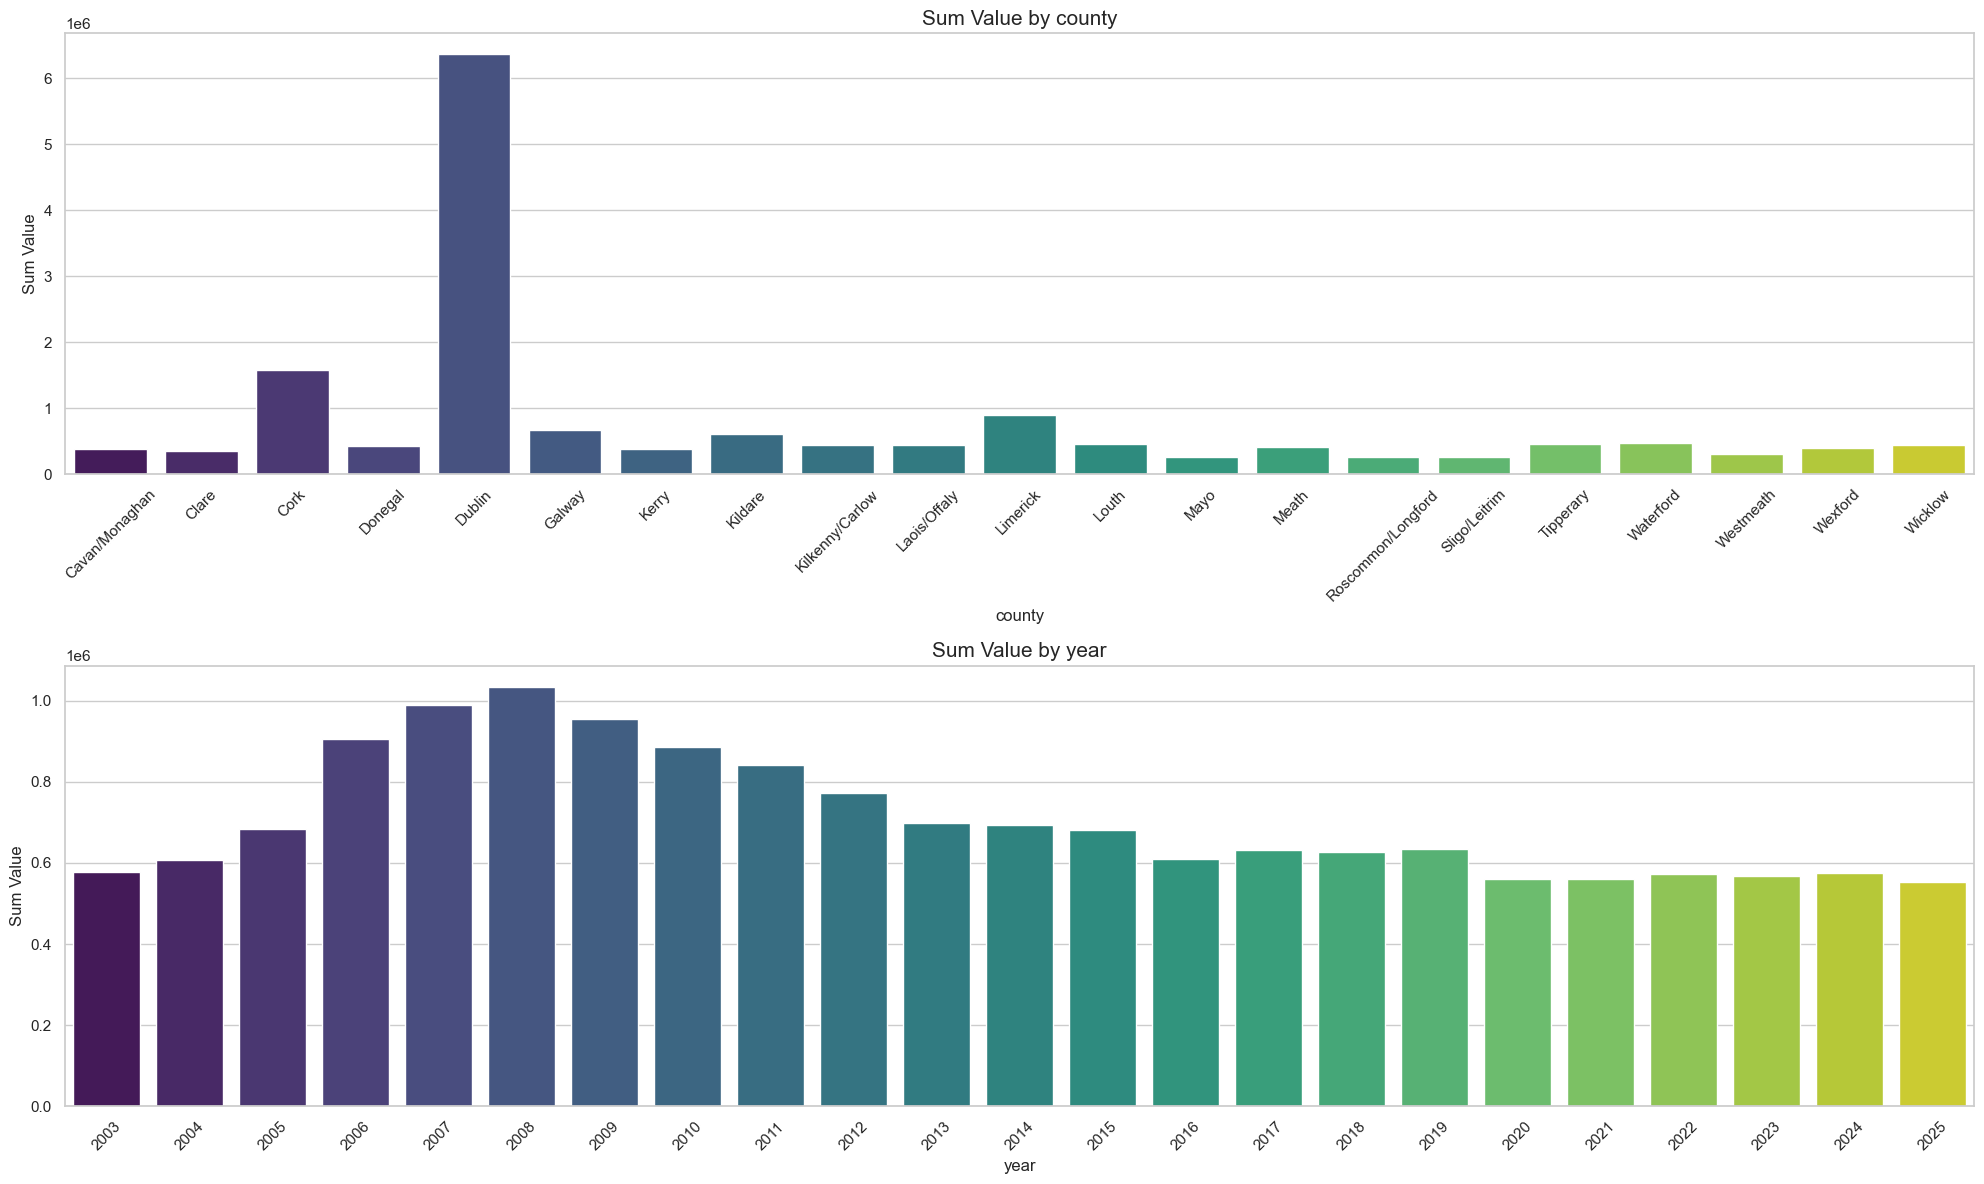

In [44]:
sns.set(style="whitegrid")

cols_to_plot = ['county', 'year']

fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=1, figsize=(20, 6 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    sns.barplot(
        data=df_summed, 
        x=col, 
        y='value', 
        estimator=sum, 
        errorbar=None, 
        ax=axes[i],
        palette='viridis'
    )
    
    axes[i].set_title(f'Sum Value by {col}', fontsize=15)
    axes[i].set_ylabel('Sum Value')
    axes[i].set_xlabel(col)
    
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

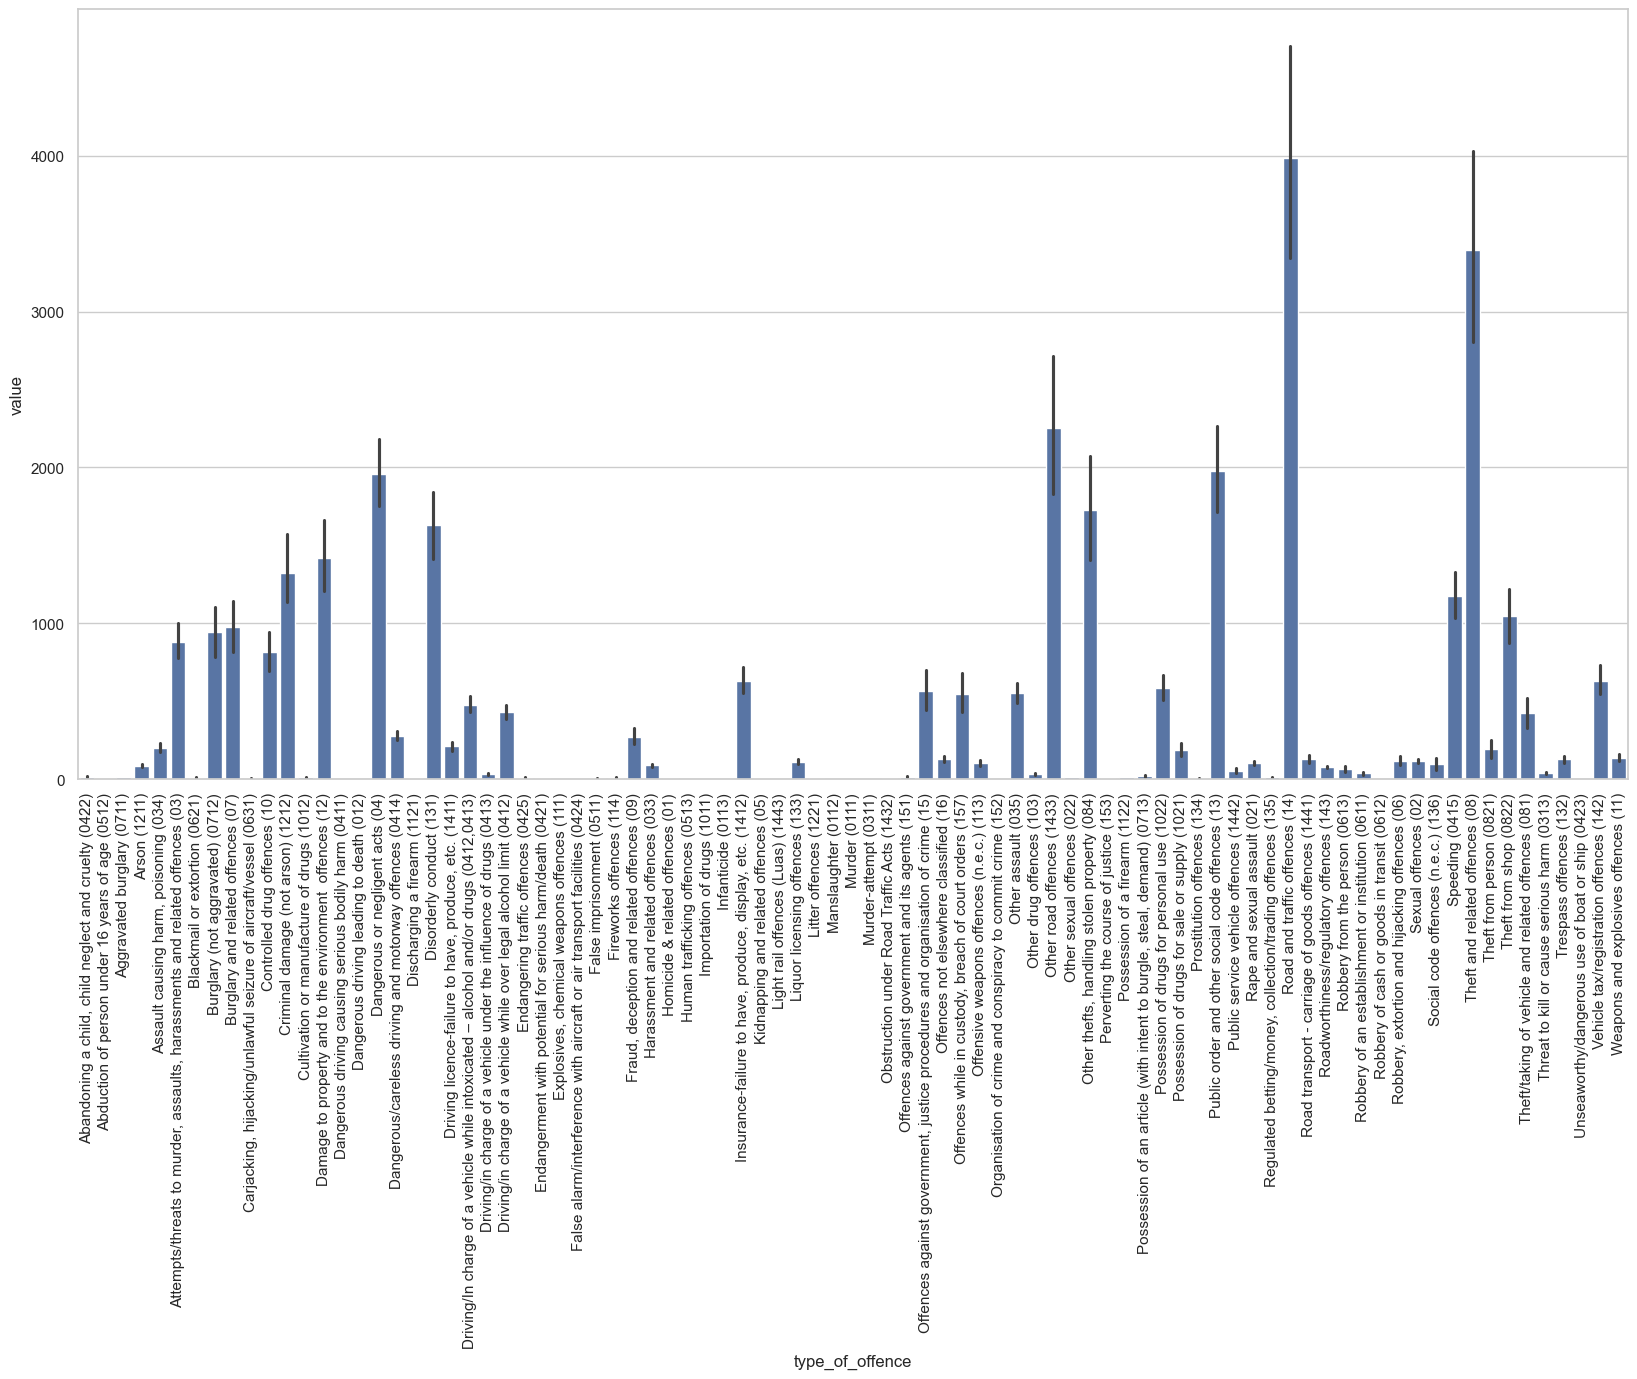

In [47]:
plt.figure(figsize=(20, 10)) 
sns.barplot(data=df_summed, x='type_of_offence', y='value')
plt.xticks(rotation=90) 
plt.show()

In [48]:
print(df_summed.dtypes)

county              object
type_of_offence     object
year                 int64
value              float64
dtype: object


In [50]:
df_summed["value"] = df_summed["value"].astype(int)

In [51]:
print(df_summed.dtypes)

county             object
type_of_offence    object
year                int64
value               int64
dtype: object


In [52]:
df_summed["county"].unique()

array(['Cavan/Monaghan', 'Clare', 'Cork', 'Donegal', 'Dublin', 'Galway',
       'Kerry', 'Kildare', 'Kilkenny/Carlow', 'Laois/Offaly', 'Limerick',
       'Louth', 'Mayo', 'Meath', 'Roscommon/Longford', 'Sligo/Leitrim',
       'Tipperary', 'Waterford', 'Westmeath', 'Wexford', 'Wicklow'],
      dtype=object)

In [53]:
data = {
    "NUTS2_Code": ["IE04"] * 6 + ["IE05"] * 8 + ["IE06"] * 7,
    
    "NUTS2_Name": (
        ["Northern & Western"] * 6 + 
        ["Southern"] * 8 + 
        ["Eastern & Midland"] * 7
    ),
    
    "NUTS3_Code": (
        ["IE041"] * 3 + ["IE042"] * 3 +        # Northern & Western
        ["IE051"] * 3 + ["IE052"] * 3 + ["IE053"] * 2 +  # Southern
        ["IE061"] * 1 + ["IE062"] * 4 + ["IE063"] * 2    # Eastern & Midland
    ),
    
    "NUTS3_Name": (
        ["Border"] * 3 + ["West"] * 3 + 
        ["Mid-West"] * 3 + ["South-East"] * 3 + ["South-West"] * 2 + 
        ["Dublin"] * 1 + ["Mid-East"] * 4 + ["Midlands"] * 2
    ),
    
    "county": [
        # Northern & Western (6)
        "Donegal", "Sligo/Leitrim", "Cavan/Monaghan", # Border
        "Galway", "Mayo", "Roscommon/Longford",      # West (Gán Ros/Lon vào đây)
        
        # Southern (8)
        "Clare", "Tipperary", "Limerick",             # Mid-West
        "Waterford", "Kilkenny/Carlow", "Wexford",    # South-East
        "Cork", "Kerry",                              # South-West
        
        # Eastern & Midland (7)
        "Dublin",                                     # Dublin
        "Wicklow", "Kildare", "Meath", "Louth",       # Mid-East
        "Westmeath", "Laois/Offaly"                   # Midlands
    ]
}

df_region_mapping = pd.DataFrame(data)

In [54]:
df_region_mapping

,NUTS2_Code,NUTS2_Name,NUTS3_Code,NUTS3_Name,county
0,IE04,Northern & Western,IE041,Border,Donegal
1,IE04,Northern & Western,IE041,Border,Sligo/Leitrim
2,IE04,Northern & Western,IE041,Border,Cavan/Monaghan
3,IE04,Northern & Western,IE042,West,Galway
4,IE04,Northern & Western,IE042,West,Mayo
5,IE04,Northern & Western,IE042,West,Roscommon/Longford
6,IE05,Southern,IE051,Mid-West,Clare
7,IE05,Southern,IE051,Mid-West,Tipperary
8,IE05,Southern,IE051,Mid-West,Limerick
9,IE05,Southern,IE052,South-East,Waterford


In [56]:
df_region_mapping.columns = [c.replace(' ', '_').lower() for c in df_region_mapping.columns]

In [57]:
df_region_mapping.head(5)

,nuts2_code,nuts2_name,nuts3_code,nuts3_name,county
0,IE04,Northern & Western,IE041,Border,Donegal
1,IE04,Northern & Western,IE041,Border,Sligo/Leitrim
2,IE04,Northern & Western,IE041,Border,Cavan/Monaghan
3,IE04,Northern & Western,IE042,West,Galway
4,IE04,Northern & Western,IE042,West,Mayo


In [61]:
pg_user = os.getenv("PG_USER")
pg_pass = os.getenv("PG_PASSWORD")
pg_host = os.getenv("PG_HOST")
pg_port = os.getenv("PG_PORT", "5432")
pg_db = os.getenv("PG_DATABASE")
pg_uri = f"postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}"
engine = create_engine(pg_uri)

In [62]:
# Pull data into 'cleaned_crime_data'
df_summed.to_sql('cleaned_crime_data', engine, if_exists='replace', index=False)

print("Successfully upload dataset into PostgreSQL!")

Successfully upload dataset into PostgreSQL!


In [63]:
df_region_mapping.to_sql("region_mapping", engine, if_exists="replace", index=False)
print("Successfully upload dataset df_region_mapping into PostgreSQL!")

Successfully upload dataset df_region_mapping into PostgreSQL!


In [64]:
sql_create_view = """
CREATE OR REPLACE VIEW crime_with_regions AS
SELECT c.*, 
    m."nuts2_name" AS "region"
FROM  cleaned_crime_data c
LEFT JOIN region_mapping m ON c.county = m."county"  ;
"""

with engine.connect() as connection:
    connection.execute(text(sql_create_view))
    connection.commit() 
    print("Successdully creat view!")

Successdully creat view!


In [65]:
sql_create_view = """
DROP VIEW IF EXISTS crime_year_county;
CREATE OR REPLACE VIEW crime_year_county AS
SELECT SUM(value) as value,
    county, 
    year,
    region AS region
FROM crime_with_regions
GROUP BY county, year, region  ;
"""

with engine.connect() as connection:
    try:
        connection.execute(text(sql_create_view))
        connection.commit()
        print("Successfully updated view: crime_year_county!")
    except Exception as e:
        print(f"Error: {e}")

Successfully updated view: crime_year_county!


In [66]:
df_check = pd.read_sql("SELECT * FROM crime_year_county LIMIT 5", engine)
print(df_check)

     value          county  year              region
0  13774.0  Cavan/Monaghan  2003  Northern & Western
1  15241.0  Cavan/Monaghan  2004  Northern & Western
2  17062.0  Cavan/Monaghan  2005  Northern & Western
3  24524.0  Cavan/Monaghan  2006  Northern & Western
4  24095.0  Cavan/Monaghan  2007  Northern & Western


In [67]:
sql_create_view = """
DROP VIEW IF EXISTS crime_year_region;
CREATE OR REPLACE VIEW crime_year_region AS
SELECT SUM(value) as value, 
    year,
    region AS region
FROM crime_with_regions
GROUP BY year, region  ;
"""

with engine.connect() as connection:
    try:
        connection.execute(text(sql_create_view))
        connection.commit()
        print("Successfully updated view: crime_year_region!")
    except Exception as e:
        print(f"Error: {e}")

Successfully updated view: crime_year_region!


In [68]:
df_check = pd.read_sql("SELECT * FROM crime_year_region LIMIT 5", engine)
print(df_check)

      value  year              region
0   79880.0  2021  Northern & Western
1  302474.0  2007            Southern
2  169031.0  2023            Southern
3   77421.0  2022  Northern & Western
4  549765.0  2007   Eastern & Midland


In [ ]:
!pip install sqlalchemy 

In [ ]:
!pip install pyjstat python-dotenv pymongo psycopg2-binary requests pandas